<a href="https://colab.research.google.com/github/gayakarapetyan/PythonCourseH2/blob/main/Session4%5CDemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 : Floods, discharge, and prediction on a real river


---
## Setup


In [ ]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Our river: the Elbe at Magdeburg. (Open-Meteo snaps to the nearest river grid cell.)
LAT, LON = 52.13, 11.63

def fetch(url, params):
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()        # turn an HTTP error into a clear Python error
    return r.json()

# The three Open-Meteo services we'll use:
FORECAST = "https://api.open-meteo.com/v1/forecast"          # weather forecast
FLOOD    = "https://flood-api.open-meteo.com/v1/flood"       # river discharge (GloFAS)
ARCHIVE  = "https://archive-api.open-meteo.com/v1/archive"   # decades of history

print("Ready. River:", LAT, LON)

Ready. River: 52.13 11.63


In [ ]:
#where to get the data
!pip install wetterdienst --quiet

from wetterdienst import Settings
from wetterdienst.provider.dwd.observation import DwdObservationRequest

settings=Settings(ts_shape="wide")

def load_weather(station_id, start, end):
    request = DwdObservationRequest(
        parameters=[("daily", "climate_summary")],
        start_date= start,
        end_date= end,
        settings=settings,
    ).filter_by_station_id(station_id=(station_id,))

    return(request.values.all().df.to_pandas())

    # get the station id
statat = 52.1316
statlon = 11.6392

nearest = request.filter_by_distance(
    latlon=(statat, statlon),
    distance=5,
    unit='km'
).df.to_pandas()   # ← always convert to pandas

print('Stations within 5 km of Magdeburg:')
print(nearest[['station_id','name','latitude','longitude','height','distance']]
      .sort_values('distance')
      .to_string(index=False))

---
# Part A

Before we build anything, let's discover what already exists for free. A huge amount of weather and water forecasting is done by national agencies and made available to everyone.

### Weather forecast: rain and temperature

Here wee ask the forecast service for the next 7 days plus the last 7 days of hourly temperature and rain. An **API** is just a URL describing what we want; the service answers with **JSON** (structured text that becomes a table).

In [ ]:
wx = fetch(FORECAST, {
    "latitude": LAT, "longitude": LON,
    "hourly": "temperature_2m,precipitation",
    "past_days": 7, "forecast_days": 7,
    "timezone": "auto",
})

w = pd.DataFrame(wx["hourly"])
print(w.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            336 non-null    object 
 1   temperature_2m  336 non-null    float64
 2   precipitation   336 non-null    float64
dtypes: float64(2), object(1)
memory usage: 8.0+ KB
None


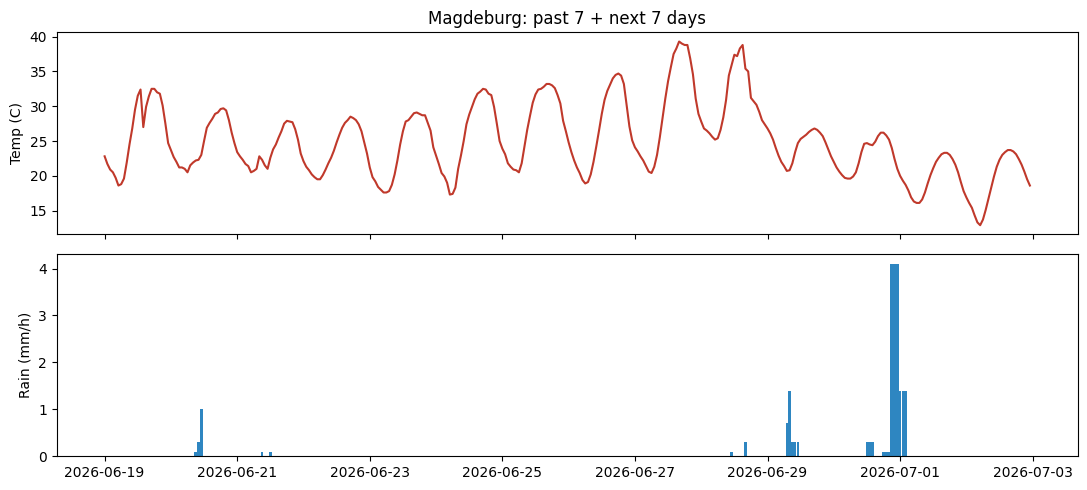

In [ ]:
w["time"] = pd.to_datetime(w["time"])

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(w["time"], w["temperature_2m"], color="#C0392B")
ax[0].set_ylabel("Temp (C)"); ax[0].set_title("Magdeburg: past 7 + next 7 days")
ax[1].bar(w["time"], w["precipitation"], width=0.04, color="#2E86C1")
ax[1].set_ylabel("Rain (mm/h)")
plt.tight_layout(); plt.show()

### A2 a river-discharge forecast

Open-Meteo serves **GloFAS** - the *Global Flood Awareness System*, run by the European Commission's Copernicus programme - which forecasts **river discharge** for rivers worldwide. Emergency services use this operationally to issue flood warnings.

We ask for the last 90 days and the next 30 days of daily discharge.

In [ ]:
fc = fetch(FLOOD, {
    "latitude": LAT, "longitude": LON,
    "daily": "river_discharge",
    "past_days": 90, "forecast_days": 30,
})
#print(fc["latitude"], fc["longitude"])  #print this if you want to see the exact coords

q = pd.DataFrame(fc["daily"])
print(q.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             120 non-null    object 
 1   river_discharge  120 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.0+ KB
None


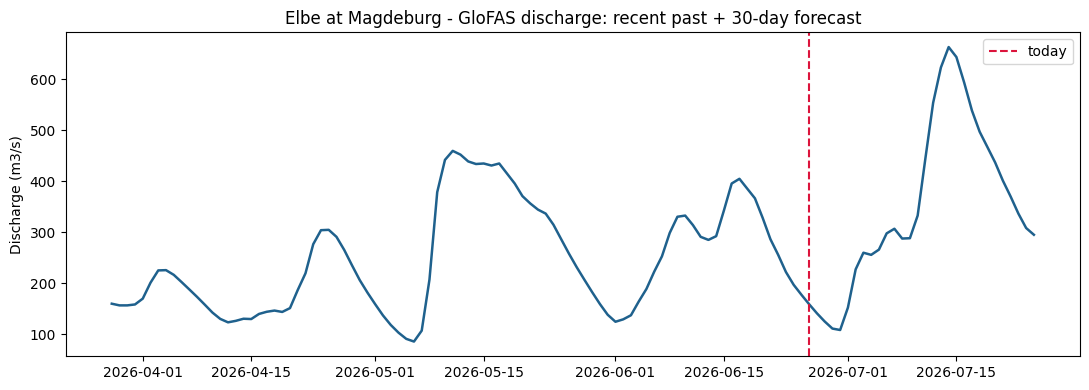

Latest value: 177.2 m3/s


In [ ]:
q["time"] = pd.to_datetime(q["time"])
today = pd.Timestamp.now().normalize()

plt.figure(figsize=(11, 4))
plt.plot(q["time"], q["river_discharge"], color="#1F618D", lw=1.8)
plt.axvline(today, color="crimson", ls="--", lw=1.5, label="today")
plt.ylabel("Discharge (m3/s)"); plt.title("Elbe at Magdeburg - GloFAS discharge: recent past + 30-day forecast")
plt.legend(); plt.tight_layout(); plt.show()

print("Latest value:", round(q["river_discharge"].dropna().iloc[-31], 1), "m3/s")

### Forecasts come with uncertainty

Nobody knows the future exactly. GloFAS actually runs its forecast *many times* with slightly different starting conditions, which gives a **range**. We can ask for the middle estimate and the 25th-75th percentile band and draw the uncertainty.

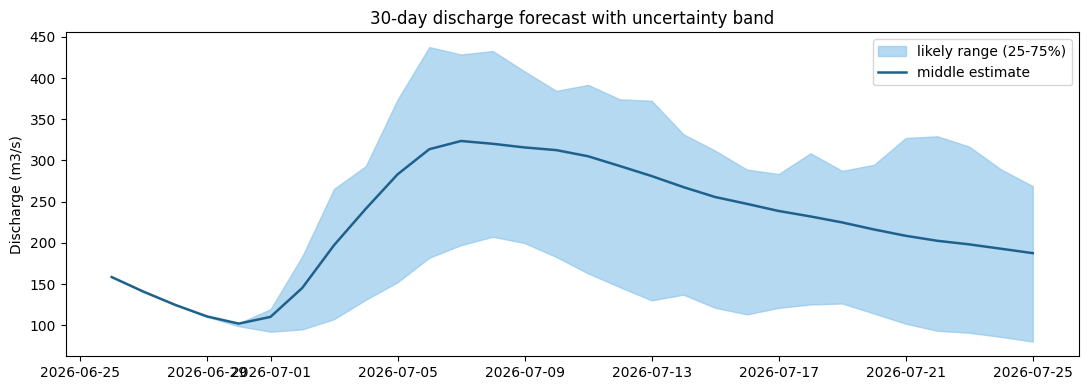

In [ ]:
try:
    ens = fetch(FLOOD, {
        "latitude": LAT, "longitude": LON,
        "daily": "river_discharge_mean,river_discharge_p25,river_discharge_p75",
        "forecast_days": 30,
    })
    e = pd.DataFrame(ens["daily"]); e["time"] = pd.to_datetime(e["time"])

    plt.figure(figsize=(11, 4))
    plt.fill_between(e["time"], e["river_discharge_p25"], e["river_discharge_p75"],
                     color="#85C1E9", alpha=0.6, label="likely range (25-75%)")
    plt.plot(e["time"], e["river_discharge_mean"], color="#1F618D", lw=1.8, label="middle estimate")
    plt.ylabel("Discharge (m3/s)"); plt.title("30-day discharge forecast with uncertainty band")
    plt.legend(); plt.tight_layout(); plt.show()
except Exception as err:
    print("Ensemble variables not available right now:", err)

### A4 - A real flood: the Elbe, June 2013

In late May / early June 2013 a storm sat over Central Europe and the Elbe reached record levels in Magdeburg, one of the largest floods in the city's modern history. Let's pull the discharge for that window from the GloFAS record and see the event in the data.

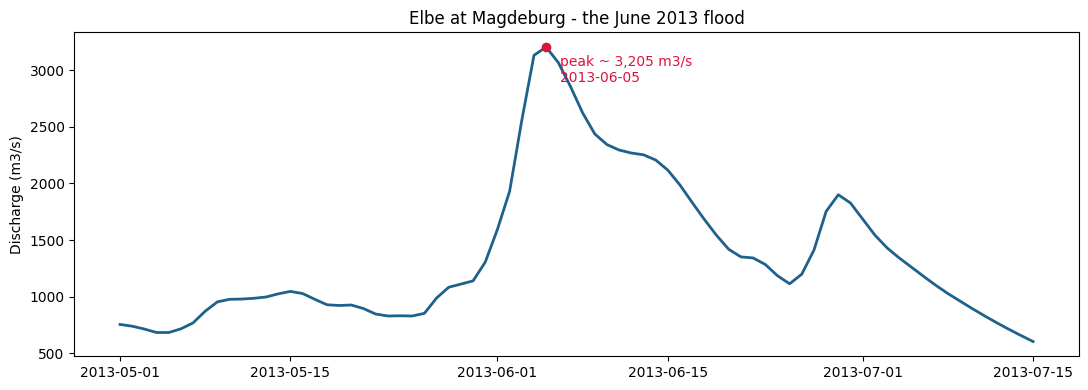

In [ ]:
event = fetch(FLOOD, {
    "latitude": LAT, "longitude": LON,
    "daily": "river_discharge",
    "start_date": "2013-05-01", "end_date": "2013-07-15",
})
ev = pd.DataFrame(event["daily"])
ev["time"] = pd.to_datetime(ev["time"])

peak_val = ev["river_discharge"].max()
peak_day = ev.loc[ev["river_discharge"].idxmax(), "time"]

plt.figure(figsize=(11, 4))
plt.plot(ev["time"], ev["river_discharge"], color="#1F618D", lw=2)
plt.scatter([peak_day], [peak_val], color="crimson", zorder=5)
plt.annotate(f"peak ~ {peak_val:,.0f} m3/s\n{peak_day.date()}",
             (peak_day, peak_val), textcoords="offset points", xytext=(10, -25), color="crimson")
plt.ylabel("Discharge (m3/s)"); plt.title("Elbe at Magdeburg - the June 2013 flood")
plt.tight_layout(); plt.show()

### Mini task

Pick a river (search '<town> latitude longitude' for a point on it) and pull its discharge forecast.

In [ ]:
#your code here!

---
# Part B

Now we build our own model.

### Get the history (discharge + rainfall)

Two downloads, merged into one daily table:
- **discharge** (our river's flow) from the GloFAS record, back to 1991, and
- **rainfall and temperature** for the same days from the weather archive (built from the ERA5 reanalysis).


In [ ]:
#  historical years of daily river discharge
dis = fetch(FLOOD, {"latitude": LAT, "longitude": LON, "daily": "river_discharge",
                    "start_date": "1991-01-01", "end_date": "2023-12-31"})
dis = pd.DataFrame(dis["daily"]).rename(columns={"river_discharge": "discharge"})

# rainfall + temperature for the same period
met = fetch(ARCHIVE, {"latitude": LAT, "longitude": LON,
                      "start_date": "1991-01-01", "end_date": "2023-12-31",
                      "daily": "precipitation_sum,temperature_2m_mean", "timezone": "auto"})
met = pd.DataFrame(met["daily"]).rename(columns={"precipitation_sum": "precip",
                                                 "temperature_2m_mean": "temp"})

# merge on the date column into one tidy table
df = pd.merge(dis, met, on="time")
df["time"] = pd.to_datetime(df["time"])
df = df.dropna().reset_index(drop=True)
print(f"{len(df)} days, {df['time'].dt.year.nunique()} years")
df.head()

9861 days, 27 years


,time,discharge,precip,temp
0,1997-01-01,198.07,0.0,-15.6
1,1997-01-02,173.98,0.0,-16.7
2,1997-01-03,153.53,1.0,-9.2
3,1997-01-04,136.09,0.0,-6.7
4,1997-01-05,122.03,0.0,-8.4


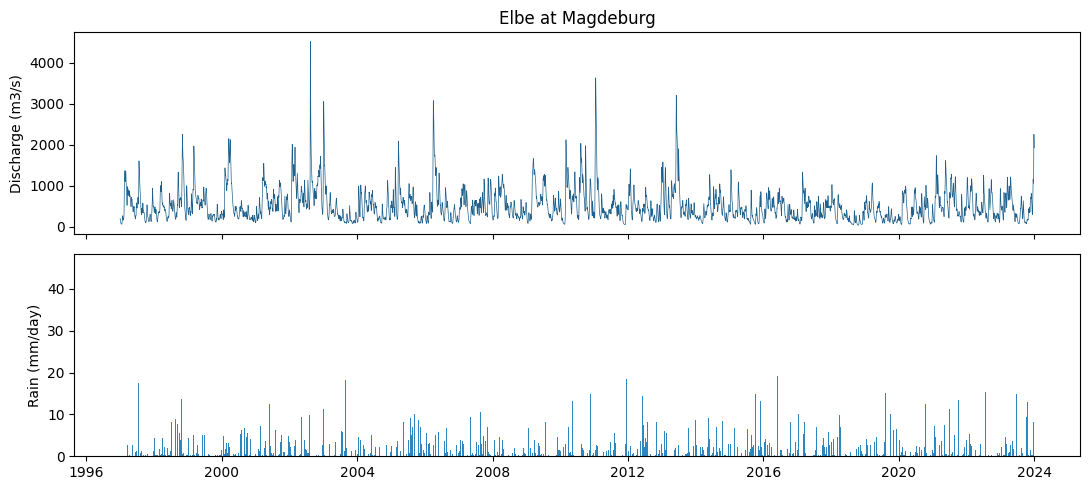

In [ ]:
# lets plot first
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(df["time"], df["discharge"], color="#1F618D", lw=0.5)
ax[0].set_ylabel("Discharge (m3/s)"); ax[0].set_title("Elbe at Magdeburg")
ax[1].bar(df["time"], df["precip"], width=1, color="#2E86C1")
ax[1].set_ylabel("Rain (mm/day)")
plt.tight_layout(); plt.show()

### Mini task

Print a few basic numbers about the discharge: its typical (median) value, its all-time maximum, and the date that maximum happened. (These one-liners are the kind of thing you should always check before modelling.)

In [ ]:
#print("Median discharge:", df["discharge"].median(), "m3/s")
# TODO: print the maximum discharge, and the date it occurred
# Hint: df["discharge"].max(), and df.loc[df["discharge"].idxmax(), "time"]

---
## Question 1
### (Flood frequency analysis - statistics)

27 yearly peaks, from 954 to 4518 m3/s


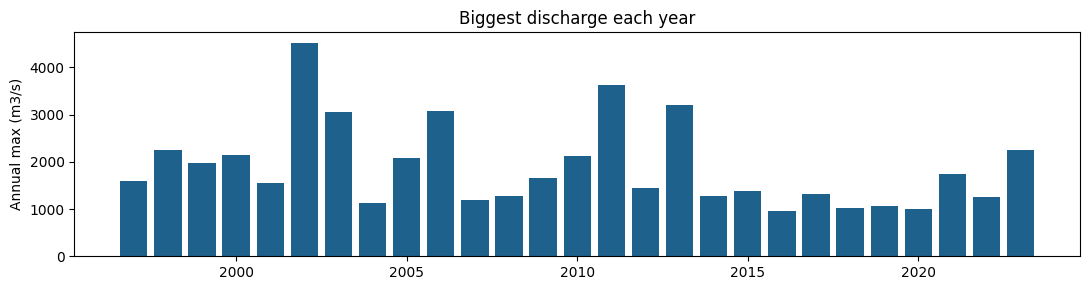

In [ ]:
# Step 1: the biggest discharge in each calendar year
annual_max = df.groupby(df["time"].dt.year)["discharge"].max()
print(f"{len(annual_max)} yearly peaks, from {annual_max.min():.0f} to {annual_max.max():.0f} m3/s")

plt.figure(figsize=(11, 3))
plt.bar(annual_max.index, annual_max.values, color="#1F618D")
plt.ylabel("Annual max (m3/s)"); plt.title("Biggest discharge each year")
plt.tight_layout(); plt.show()

In [ ]:
# fit a Gumbel distribution to the yearly peaks
from scipy.stats import gumbel_r

loc, scale = gumbel_r.fit(annual_max.values)

# Step 3: discharge for a given return period
def design_flood(T):
    return gumbel_r.ppf(1 - 1/T, loc, scale)

for T in [2, 5, 10, 20, 50]:
    print(f"  {T:3d}-year flood:  {design_flood(T):7.0f} m3/s")

    2-year flood:     1731 m3/s
    5-year flood:     2399 m3/s
   10-year flood:     2841 m3/s
   20-year flood:     3265 m3/s
   50-year flood:     3815 m3/s


### mini task

Use the `design_flood` function to estimate the **100-year** flood, and say how much bigger it is than the 50-year flood.

---
## Question 2 - Given the rain, how high will the river get?

**The features** (what the model is allowed to see): rain today, rain on each of the last 3 days (to capture delay), the **7-day rolling rainfall total** (to capture how wet the ground already is - the "memory"), temperature, and the time of year.

In [ ]:
d = df.sort_values("time").reset_index(drop=True).copy()

# rainfall delay: how much it rained on each of the previous days
d["precip_lag1"] = d["precip"].shift(1)
d["precip_lag2"] = d["precip"].shift(2)
d["precip_lag3"] = d["precip"].shift(3)
# catchment memory: total rain over the last 7 days, how much water is in the ground
d["precip_7day"] = d["precip"].rolling(7).sum()
# time of year
doy = d["time"].dt.dayofyear
d["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
d["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)

d = d.dropna().reset_index(drop=True)
features = ["precip", "precip_lag1", "precip_lag2", "precip_lag3",
           "precip_7day", "temp", "sin_doy", "cos_doy"]
target = "discharge"
d[["time"] + features + [target]].head()

,time,precip,precip_lag1,precip_lag2,precip_lag3,precip_7day,temp,sin_doy,cos_doy,discharge
0,1997-01-07,0.0,0.0,0.0,0.0,1.0,-7.1,0.120126,0.992759,99.00
1,1997-01-08,0.0,0.0,0.0,0.0,1.0,-8.1,0.137185,0.990545,90.62
2,1997-01-09,0.0,0.0,0.0,0.0,1.0,-5.5,0.154204,0.988039,83.72
3,1997-01-10,0.0,0.0,0.0,0.0,0.0,-4.8,0.171177,0.985240,78.07
4,1997-01-11,0.0,0.0,0.0,0.0,0.0,-4.1,0.188099,0.982150,73.13


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def nse(observed, simulated):
    """Nash-Sutcliffe Efficiency - the R-squared."""
    observed, simulated = np.asarray(observed), np.asarray(simulated)
    return 1 - np.sum((observed - simulated)**2) / np.sum((observed - observed.mean())**2)

split = int(len(d) * 0.8)
train, test = d.iloc[:split], d.iloc[split:]

model = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)
model.fit(train[features], train[target])
pred = model.predict(test[features])

print(f"NSE : {nse(test[target], pred):.2f}   (1.0 = perfect, 0.0 = no better than the mean)")
print(f"MAE : {mean_absolute_error(test[target], pred):.1f} m3/s")

NSE : -0.06   (1.0 = perfect, 0.0 = no better than the mean)
MAE : 257.1 m3/s


precip_7day    0.249
sin_doy        0.190
temp           0.163
cos_doy        0.128
precip         0.073
precip_lag3    0.066
precip_lag2    0.065
precip_lag1    0.065
dtype: float64


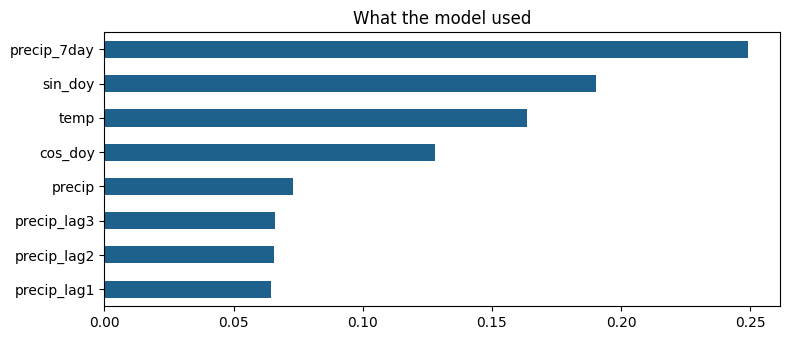

In [ ]:
# Which features did the model lean on? This reveals the catchment's behaviour.
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importance.round(3))

importance.iloc[::-1].plot(kind="barh", figsize=(8, 3.5), color="#1F618D")
plt.title("What the model used"); plt.tight_layout(); plt.show()

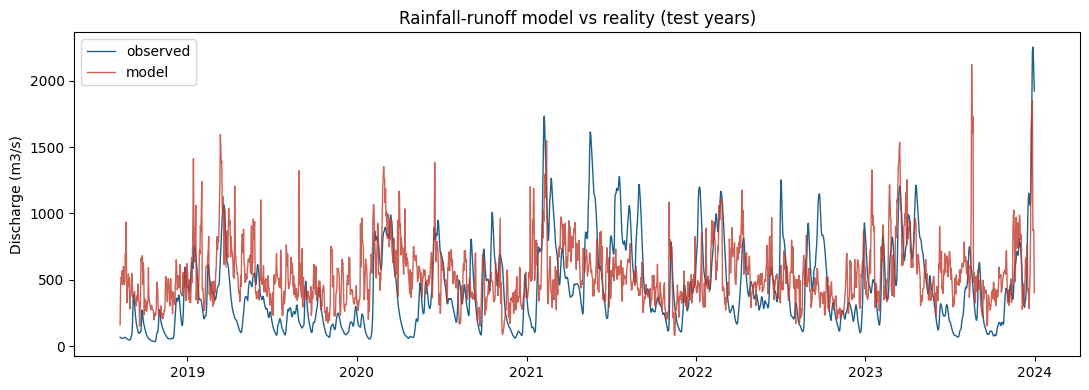

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(test["time"], test[target].values, color="#1F618D", lw=1, label="observed")
plt.plot(test["time"], pred, color="#C0392B", lw=1, alpha=0.8, label="model")
plt.ylabel("Discharge (m3/s)"); plt.title("Rainfall-runoff model vs reality (test years)")
plt.legend(); plt.tight_layout(); plt.show()

### Mini task

(1) remove the `precip_7day` memory feature and see how much the NSE drops - that tells you how much catchment memory matters; (2) optionally try a neural network (`MLPRegressor`) instead of the forest.

In [ ]:
feats_no_memory = ["precip", "precip_lag1", "precip_lag2", "precip_lag3",
                   "temp", "sin_doy", "cos_doy"]   # dropped precip_7day
m2 = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)
m2.fit(train[feats_no_memory], train[target])
print(f"NSE without the 7-day memory: {nse(test[target], m2.predict(test[feats_no_memory])):.2f}")
print(f"NSE with everything:          {nse(test[target], pred):.2f}")
# TODO (optional): train an MLPRegressor on the full `features` and print its NSE.

NSE without the 7-day memory: -0.20
NSE with everything:          -0.06


<details>
<summary><b>Show a solution</b></summary>

```python
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
nn = make_pipeline(StandardScaler(),
                   MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=2000, random_state=0))
nn.fit(train[features], train[target])
print(f"Neural network NSE: {nse(test[target], nn.predict(test[features])):.2f}")
```

</details>

---
## Question 3 Flood early-warning - classification

We set the danger line at a high percentile of the record (here the 95th - a level reached only on the wettest ~5% of days) and label each day by whether *tomorrow* crosses it.

In [ ]:
danger = df["discharge"].quantile(0.95)
print(f"Danger level (95th percentile): {danger:,.0f} m3/s")

c = d.copy()
c["flood_tomorrow"] = (c["discharge"].shift(-1) > danger).astype(int)  # 1 = flood, 0 = safe
c = c.dropna().reset_index(drop=True)

# Today's discharge is known now, so it's allowed as a feature alongside the rain history.
clf_features = ["discharge", "precip", "precip_lag1", "precip_lag2", "precip_7day", "temp"]

print(f"Flood days in the record: {c['flood_tomorrow'].mean():.1%}  -> floods are RARE")

Danger level (95th percentile): 1,218 m3/s
Flood days in the record: 5.0%  -> floods are RARE


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

split = int(len(c) * 0.8)
ctrain, ctest = c.iloc[:split], c.iloc[split:]

# class_weight="balanced" tells the model to take the rare flood days seriously
clf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1, class_weight="balanced")
clf.fit(ctrain[clf_features], ctrain["flood_tomorrow"])
pred_c = clf.predict(ctest[clf_features])

y = ctest["flood_tomorrow"]
print(f"'Always say no' accuracy: {1 - y.mean():.1%}   <- the trap")
print(f"Our model accuracy:       {accuracy_score(y, pred_c):.1%}")
print()
print(f"Recall    (floods caught):   {recall_score(y, pred_c):.0%}")
print(f"Precision (warnings correct):{precision_score(y, pred_c):.0%}")

'Always say no' accuracy: 98.4%   <- the trap
Our model accuracy:       99.3%

Recall    (floods caught):   77%
Precision (warnings correct):80%


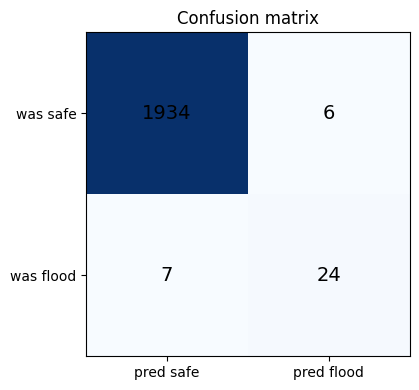

Bottom-left = floods we MISSED (the dangerous mistake).
Top-right   = false alarms (cry wolf).


In [ ]:
# The confusion matrix lays out exactly where we were right and wrong.
cm = confusion_matrix(y, pred_c)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred safe", "pred flood"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["was safe", "was flood"])
ax.set_title("Confusion matrix"); plt.tight_layout(); plt.show()

print("Bottom-left = floods we MISSED (the dangerous mistake).")
print("Top-right   = false alarms (cry wolf).")

### Your turn - move the danger line

Change the danger level to a stricter one (the 99th percentile - only the most extreme days). Rebuild the labels and retrain. Watch how the flood rate, recall and precision change when the events get rarer.

In [ ]:
danger99 = df["discharge"].quantile(0.99)
print(f"Stricter danger level: {danger99:,.0f} m3/s")
# TODO: rebuild c["flood_tomorrow"] using danger99, re-split, retrain the classifier,
#       and print recall & precision. (Copy the cells above and swap `danger` -> `danger99`.)

Stricter danger level: 1,922 m3/s


<details>
<summary><b>Show a solution</b></summary>

```python
c2 = d.copy()
c2["flood_tomorrow"] = (c2["discharge"].shift(-1) > danger99).astype(int)
c2 = c2.dropna().reset_index(drop=True)
s = int(len(c2) * 0.8); tr2, te2 = c2.iloc[:s], c2.iloc[s:]
clf2 = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1, class_weight="balanced")
clf2.fit(tr2[clf_features], tr2["flood_tomorrow"])
p2 = clf2.predict(te2[clf_features])
print(f"Flood rate: {c2['flood_tomorrow'].mean():.1%}")
print(f"Recall: {recall_score(te2['flood_tomorrow'], p2):.0%}  Precision: {precision_score(te2['flood_tomorrow'], p2):.0%}")
# Rarer events are harder: recall usually drops as the danger line rises.
```

</details>

---
## Wrap-up, and the student project

On one real river we answered three real questions:
- **Q1 (statistics):** fitted extreme-value statistics to estimate the **design flood** - the number a bridge or levee is built against.
- **Q2 (regression):** learned the **rainfall-to-runoff** mapping, scored it with **NSE**, and let feature importance reveal how the catchment behaves.
- **Q3 (classification):** built a **flood early-warning** classifier and learned why **accuracy lies** for rare events - recall and precision are what count.

**The project assignment writes itself:** each student picks their **own river** (change `LAT`, `LON` at the top) and answers the same three questions for it. Same pipeline, a different catchment each - easy to assign, easy to compare, and genuinely useful.

A few honest pointers for them (and you, when helping):
- *Flood frequency (Q1)* is the most reliable and hardest to get wrong - a safe core for every project.
- *Rainfall-runoff (Q2)* is the most impressive but needs the most care with features and the time-ordered split.
- *Classification (Q3)* lives or dies on remembering that rare events make accuracy meaningless.

Next, we leave the notebook and turn this kind of analysis into a proper, reusable **script** - and learn to run a long job in the terminal so it survives closing your laptop.